### Utils

In [230]:
import os 
import ast

def load_choi_blocks(filename: str) -> dict:
    if not os.path.exists(filename):
        raise FileNotFoundError(f"파일 없음: {filename}")

    blocks = {}
    with np.load(filename, allow_pickle=True) as data:
        for k in data.files:
            try:
                # ast.literal_eval을 사용하여 "(5, 2)" -> (5, 2) 복원
                key_tuple = ast.literal_eval(k)
                blocks[key_tuple] = data[k].copy()
            except (ValueError, SyntaxError):
                # 변환 불가능한 키는 스킵
                continue
    return blocks


import numpy as np
from IPython.display import display, Math

def val_to_latex(val, tol=1e-10):
    """
    수치값을 LaTeX 문자열로 변환 (양자 클로닝에서 자주 쓰이는 무리수/분수 감지)
    """
    
    if val is None: return "0"
    if isinstance(val, complex):
        if abs(val.imag) < tol: val = val.real
        
    if abs(val) < tol:  return "0"
    
    # 기호 매핑 (필요에 따라 추가 가능)
    symbol_map = {
        1/2: r"\frac{1}{2}",
        1/3: r"\frac{1}{3}",
        2/3: r"\frac{2}{3}",
        1/6: r"\frac{1}{6}",
        np.sqrt(2)/3: r"\frac{\sqrt{2}}{3}",
        np.sqrt(2): r"\sqrt{2}",
        1/np.sqrt(2): r"\frac{1}{\sqrt{2}}",
        np.sqrt(3): r"\sqrt{3}",
        1.0: "1",
        -1.0: "-1"
    }
    
    sign = "-" if val < 0 else ""
    abs_val = abs(val)
    
    for num, latex in symbol_map.items():
        if abs(abs_val - num) < tol:
            return f"{sign}{latex}"
            
    # 매핑되지 않은 수는 소수점 3자리까지 표시
    return f"{val:.7f}"

def matrix_to_latex(mat, tol=1e-9):
    """
    Numpy array -> LaTeX bmatrix string
    """
    if mat is None: return r"\text{None}"
    
    rows, cols = mat.shape
    lines = []
    for i in range(rows):
        line = [val_to_latex(mat[i, j], tol=tol) for j in range(cols)]
        lines.append(" & ".join(line))
    
    return r"\begin{pmatrix}" + " \\\\ ".join(lines) + r"\end{pmatrix}"

def display_irrep_maps(irrep_dict, tol=1e-9):
    """
    Dictionary {(j2_out, j2_in): matrix}를 입력받아
    Jupyter Notebook상에 LaTeX 수식으로 렌더링합니다.
    """
    # Key를 정렬 (Input Spin 오름차순 -> Output Spin 오름차순)
    sorted_keys = sorted(irrep_dict.keys(), key=lambda x: (x[1], x[0]))
    
    for (j2_out, j2_in) in sorted_keys:
        matrix = irrep_dict[(j2_out, j2_in)]
        
        # j2 (2*spin) 값을 Spin 값으로 변환
        s_in = j2_in / 2
        s_out = j2_out / 2
        
        # 정수면 .0 떼기 (예: 1.0 -> 1)
        str_in = f"{int(s_in)}" if s_in.is_integer() else f"{s_in}"
        str_out = f"{int(s_out)}" if s_out.is_integer() else f"{s_out}"
        
        # 행렬 LaTeX 변환
        tex_mat = matrix_to_latex(matrix, tol=tol)
        
        # 최종 수식 구성: J_{in -> out} = Matrix
        latex_eq = rf"J_{{{str_in} \to {str_out}}} = {tex_mat}"
        
        # 렌더링
        display(Math(latex_eq))

# --- 테스트 데이터 (사용자의 데이터 예시) ---
# irrep_maps = {(2, 1): J_triplet, (0, 1): J_singlet} 같은 딕셔너리
# display_irrep_maps(irrep_maps)

### Find irrep maps

### Solver

In [231]:
import numpy as np
import pandas as pd
import cvxpy as cp
from math import comb


# ============================================================
# 0) Basic combinatorics / Schur-Weyl bookkeeping (qubits)
# ============================================================
def j2_list_for_n_qubits(n: int):
    """Return list of j2=2j: n, n-2, ..., (n mod 2)."""
    return list(range(n, n % 2 - 1, -2))


def mult_qubits_exact(n: int, j2: int) -> int:
    """
    Multiplicity m_{j,n} for qubits in Schur-Weyl:
      (C^2)^{⊗n} ≅ ⊕_j (U_j ⊗ V_j),  dim(V_j)=m_{j,n}

    Exact integer formula:
      m_{j,n} = C(n,k) - C(n,k-1),  k=(n-j2)/2
    """
    if j2 < 0 or j2 > n or (n - j2) % 2 != 0:
        return 0
    k = (n - j2) // 2
    return comb(n, k) - (comb(n, k - 1) if k - 1 >= 0 else 0)


def young_shape_from_j2(n: int, j2: int):
    """For qubits: Young shape (n1,n2) with n1+n2=n, n1-n2=j2."""
    n1 = (n + j2) // 2
    n2 = (n - j2) // 2
    return (n1, n2) if n2 > 0 else (n1,)


# ============================================================
# 1) SU(2) spin matrices and SU(2)-commutant projectors Π_L
# ============================================================
def spin_matrices_from_j2(j2: int):
    """
    Spin-j matrices (Jx,Jy,Jz) in |j,m> basis ordered m=j,j-1,...,-j.
    j2 = 2j (integer), dimension = j2+1.
    """
    j = j2 / 2.0
    d = j2 + 1
    m_vals = np.arange(j, -j - 1, -1)

    # Correct J_+ construction for descending-m ordering:
    # J_+|j,m> = sqrt((j-m)(j+m+1)) |j,m+1>
    # Column corresponds to |j,m>, row corresponds to |j,m+1>.
    Jp = np.zeros((d, d), dtype=complex)
    for col in range(1, d):
        m = m_vals[col]
        Jp[col - 1, col] = np.sqrt((j - m) * (j + m + 1.0))

    Jm = Jp.conj().T
    Jx = (Jp + Jm) / 2.0
    Jy = (Jp - Jm) / (2.0 * 1j)
    Jz = np.diag(m_vals.astype(float))
    return Jx, Jy, Jz


def su2_commutant_projectors(j2_out: int, j2_in: int, tol: float = 1e-9):
    """
    Build orthogonal projectors Π_L onto irreps of the joint SU(2) action generated by:
        G_k = S_out^(k) ⊗ I  -  I ⊗ (S_in^(k))^T
    using the Casimir G^2.

    Returns list of (L2, Π_L) with L2=2L.
    """
    d_out = j2_out + 1
    d_in = j2_in + 1
    Iout = np.eye(d_out, dtype=complex)
    Iin = np.eye(d_in, dtype=complex)

    Sx_o, Sy_o, Sz_o = spin_matrices_from_j2(j2_out)
    Sx_i, Sy_i, Sz_i = spin_matrices_from_j2(j2_in)

    Gx = np.kron(Sx_o, Iin) - np.kron(Iout, Sx_i.T)
    Gy = np.kron(Sy_o, Iin) - np.kron(Iout, Sy_i.T)
    Gz = np.kron(Sz_o, Iin) - np.kron(Iout, Sz_i.T)

    G2 = Gx @ Gx + Gy @ Gy + Gz @ Gz
    G2 = (G2 + G2.conj().T) / 2.0

    evals, evecs = np.linalg.eigh(G2)

    L2_min = abs(j2_out - j2_in)
    L2_max = j2_out + j2_in

    projectors = []
    for L2 in range(L2_min, L2_max + 1, 2):
        L = L2 / 2.0
        target = L * (L + 1.0)
        idx = np.where(np.abs(evals - target) <= tol)[0]
        if len(idx) == 0:
            raise RuntimeError(
                f"Projector build failed for (j2_out={j2_out}, j2_in={j2_in}, L2={L2}). "
                f"target={target}, eigs(min..max)=({evals.min()}..{evals.max()})"
            )
        P = evecs[:, idx] @ evecs[:, idx].conj().T
        P = (P + P.conj().T) / 2.0
        projectors.append((L2, P))
    return projectors


# ============================================================
# 2) ρ(p)^{⊗n} block on U_j, with robust endpoint handling
# ============================================================
def rho_spin_block(n: int, j2: int, p: float,
                   normalize: bool,
                   zero_trace_policy: str = "skip",
                   eps: float = 1e-15):
    """
    Spin-j block of rho(p)^{⊗n} restricted to U_j in the |j,m> basis (m=j..-j).

    - normalize=False:
        returns subnormalized block (can be all-zero for some j at p=0 or 1; that's OK).
    - normalize=True:
        returns trace-1 (conditional) state on U_j when trace>0.
        if trace==0:
          * zero_trace_policy="limit":
              return limiting pure projector: |j,m=j><...| for p>=1/2, |j,m=-j> for p<1/2
          * "skip": return None
          * "raise": raise RuntimeError

    NOTE:
      For p=1, only the fully symmetric sector j=n/2 has nonzero subnormalized block.
      Other blocks have trace=0, so conditional normalization is undefined unless using "limit".
    """
    p = float(p)
    if p < 0.0 or p > 1.0:
        raise ValueError("p must be in [0,1].")

    d = j2 + 1
    m2_vals = np.arange(j2, -j2 - 1, -2, dtype=int)
    expp = (n + m2_vals) // 2
    expq = (n - m2_vals) // 2

    q = 1.0 - p

    # --- endpoints p≈0 or p≈1 ---
    if p <= eps or q <= eps:
        if not normalize:
            vals = np.zeros(d, dtype=float)
            # Only j2==n survives for true rho^{⊗n} at the endpoints
            if j2 == n:
                if q <= eps:   # p≈1
                    vals[0] = 1.0    # |j,m=j>
                else:          # p≈0
                    vals[-1] = 1.0   # |j,m=-j>
            return np.diag(vals).astype(complex)

        # normalize=True:
        # if j2==n, conditional block is well-defined (pure extremal weight)
        if j2 == n:
            vals = np.zeros(d, dtype=float)
            vals[0 if q <= eps else -1] = 1.0
            return np.diag(vals).astype(complex)

        # trace==0 for other blocks -> policy
        if zero_trace_policy == "skip":
            return None
        if zero_trace_policy == "raise":
            raise RuntimeError(f"Trace=0 for (n={n}, j2={j2}) at p={p}.")
        # "limit"
        vals = np.zeros(d, dtype=float)
        vals[0 if p >= 0.5 else -1] = 1.0
        return np.diag(vals).astype(complex)

    # --- interior 0<p<1 ---
    if not normalize:
        vals = (p ** expp) * (q ** expq)
        return np.diag(vals.astype(float)).astype(complex)

    # normalize=True (log-stable)
    logp = np.log(p)
    logq = np.log(q)
    logw = expp * logp + expq * logq
    m = float(np.max(logw))
    w = np.exp(logw - m)
    s = float(np.sum(w))
    if s <= 0:
        if zero_trace_policy == "skip":
            return None
        if zero_trace_policy == "raise":
            raise RuntimeError(f"Normalization failed for (n={n}, j2={j2}, p={p}).")
        vals = np.zeros(d, dtype=float)
        vals[0 if p >= 0.5 else -1] = 1.0
        return np.diag(vals).astype(complex)

    w = w / s
    return np.diag(w.astype(float)).astype(complex)


# ============================================================
# 3) Numpy-side Choi application / partial trace for evaluation
# ============================================================
def partial_trace_numpy(A: np.ndarray, d_out: int, d_in: int, axis: int):
    """
    Partial trace for matrix on H_out ⊗ H_in with dims (d_out, d_in).
    axis=0: trace out output -> (d_in,d_in)
    axis=1: trace out input  -> (d_out,d_out)
    """
    A4 = A.reshape(d_out, d_in, d_out, d_in)
    if axis == 0:
        return np.einsum("o i o j -> i j", A4)
    elif axis == 1:
        return np.einsum("o i p i -> o p", A4)
    else:
        raise ValueError("axis must be 0 or 1")


def apply_choi_block_numpy(J: np.ndarray, rho_in: np.ndarray, d_out: int, d_in: int) -> np.ndarray:
    """
    σ = Tr_in[(I ⊗ rho_in^T) J]
    """
    K = np.kron(np.eye(d_out, dtype=complex), rho_in.T)
    M = K @ J
    sigma = partial_trace_numpy(M, d_out, d_in, axis=1)
    return (sigma + sigma.conj().T) / 2.0


def root_fidelity_numpy(rho: np.ndarray, sigma: np.ndarray) -> float:
    """
    sqrtF = Tr sqrt( sqrt(rho) sigma sqrt(rho) ), for PSD matrices.
    """
    rho = (rho + rho.conj().T) / 2.0
    sigma = (sigma + sigma.conj().T) / 2.0
    w, V = np.linalg.eigh(rho)
    w = np.clip(w, 0.0, None)
    sqrt_rho = (V * np.sqrt(w)) @ V.conj().T
    C = sqrt_rho @ sigma @ sqrt_rho
    C = (C + C.conj().T) / 2.0
    wc, _ = np.linalg.eigh(C)
    wc = np.clip(wc, 0.0, None)
    return float(np.sum(np.sqrt(wc)).real)


def choose_cvxpy_solver(preference=("MOSEK", "SCS", "CVXOPT", "CLARABEL")):
    installed = set(cp.installed_solvers())
    for s in preference:
        if s in installed:
            return s
    raise RuntimeError(f"No suitable SDP solver found. Installed: {sorted(installed)}")


# ============================================================
# 4) Global solver: SolverSDPPerm (unnormalized blocks)
# ============================================================
class SolverSDPPerm:
    """
    Global SDP with:
      - permutation invariance (via Schur-Weyl reduced blocks and multiplicity weights),
      - SU(2) covariance (via projector parameterization),
      - worst-case root fidelity over p in [0.5,1] approximated by constraint generation.

    Returns reduced blocks J_blocks[(j2o,j2i)] on U_{j_o} ⊗ U_{j_i}.
    """

    def __init__(self, n_in: int, n_out: int, dim: int = 2, verbose: bool = False,
                 p_init_grid: int = 5, p_fine_grid: int = 51, n_rounds: int = 3,
                 solver_preference=("MOSEK", "SCS")):
        if dim != 2:
            raise ValueError("This implementation assumes qubits (dim=2).")
        self.n_in = n_in
        self.n_out = n_out
        self.dim = dim
        self.verbose = verbose

        self.p_init_grid = p_init_grid
        self.p_fine_grid = p_fine_grid
        self.n_rounds = n_rounds
        self.solver_preference = solver_preference

        # spin sectors + multiplicities
        self.j2_in_list = j2_list_for_n_qubits(n_in)
        self.j2_out_list = j2_list_for_n_qubits(n_out)
        self.mult_in = {j2: mult_qubits_exact(n_in, j2) for j2 in self.j2_in_list}
        self.mult_out = {j2: mult_qubits_exact(n_out, j2) for j2 in self.j2_out_list}

        # precompute commutant projectors
        self.P = {}
        for j2o in self.j2_out_list:
            for j2i in self.j2_in_list:
                self.P[(j2o, j2i)] = su2_commutant_projectors(j2o, j2i)

        self.p_samples = []

    def make_problem(self):
        t = cp.Variable()
        constraints = [t >= 0, t <= 1]

        # variables: coefficients for each projector in each block
        coeff = {}   # (j2o,j2i,L2)-> scalar var >=0
        Jexpr = {}   # (j2o,j2i) -> affine Hermitian expression

        for j2o in self.j2_out_list:
            for j2i in self.j2_in_list:
                terms = []
                for (L2, Pi) in self.P[(j2o, j2i)]:
                    x = cp.Variable(nonneg=True)
                    coeff[(j2o, j2i, L2)] = x
                    terms.append(x * cp.Constant(Pi))
                Jexpr[(j2o, j2i)] = sum(terms)

        # TP: for each input spin sector j2i
        # Σ_{j2o} m_out(j2o) * Tr_out( J_{j2o,j2i} ) = I_{d_in}
        for j2i in self.j2_in_list:
            d_in = j2i + 1
            lhs = 0
            for j2o in self.j2_out_list:
                d_out = j2o + 1
                ptr = cp.partial_trace(Jexpr[(j2o, j2i)], (d_out, d_in), axis=0)
                lhs += self.mult_out[j2o] * ptr
            constraints += [lhs == np.eye(d_in, dtype=complex)]

        # Fidelity constraints on sampled p (GLOBAL USES UNNORMALIZED BLOCKS)
        for p in self.p_samples:
            # unnormalized blocks
            rho_in = {j2i: rho_spin_block(self.n_in, j2i, float(p),
                                          normalize=False)
                      for j2i in self.j2_in_list}
            alpha_out = {j2o: rho_spin_block(self.n_out, j2o, float(p),
                                             normalize=False)
                         for j2o in self.j2_out_list}

            # sigma blocks
            sigma = {}
            for j2o in self.j2_out_list:
                d_out = j2o + 1
                sig = 0
                for j2i in self.j2_in_list:
                    d_in = j2i + 1
                    K = np.kron(np.eye(d_out, dtype=complex), rho_in[j2i].T)
                    M = cp.Constant(K) @ Jexpr[(j2o, j2i)]
                    sig_part = cp.partial_trace(M, (d_out, d_in), axis=1)
                    sig += self.mult_in[j2i] * sig_part
                sigma[j2o] = (sig + sig.H) / 2

            # blockwise root-fidelity LMIs + multiplicity-weighted sum >= t
            fid_sum = 0
            for j2o in self.j2_out_list:
                d_out = j2o + 1
                X = cp.Variable((d_out, d_out), complex=True)
                A = cp.Constant(alpha_out[j2o])
                block = cp.bmat([[A, X],
                                 [X.H, sigma[j2o]]])
                constraints += [block >> 0]
                fid_sum += self.mult_out[j2o] * cp.real(cp.trace(X))

            constraints += [fid_sum >= t]

        prob = cp.Problem(cp.Maximize(t), constraints)
        return prob, coeff, t

    def solve_one_round(self):
        prob, coeff, t = self.make_problem()
        solver = choose_cvxpy_solver(self.solver_preference)
        prob.solve(solver=solver, verbose=self.verbose)

        if t.value is None:
            raise RuntimeError("Global solver failed: t.value is None")

        # build numeric reduced blocks
        J_blocks = {}
        for j2o in self.j2_out_list:
            for j2i in self.j2_in_list:
                d_out = j2o + 1
                d_in = j2i + 1
                J = np.zeros((d_out * d_in, d_out * d_in), dtype=complex)
                for (L2, Pi) in self.P[(j2o, j2i)]:
                    x = coeff[(j2o, j2i, L2)].value
                    if x is None:
                        raise RuntimeError("Global solver failed: some coefficient is None")
                    J += float(x) * Pi
                J_blocks[(j2o, j2i)] = (J + J.conj().T) / 2.0

        return float(t.value), J_blocks

    def solve(self):
        self.p_samples = sorted(set(np.linspace(0.5, 1.0, self.p_init_grid).tolist()))

        best = None
        for it in range(self.n_rounds):
            t_opt, J_blocks = self.solve_one_round()

            # find worst p on fine grid (evaluate global objective directly via blocks)
            p_fine = np.linspace(0.5, 1.0, self.p_fine_grid)
            fvals = []
            for p in p_fine:
                # build sigma blocks in numpy
                rho_in = {j2i: rho_spin_block(self.n_in, j2i, float(p), normalize=False)
                          for j2i in self.j2_in_list}
                alpha = {j2o: rho_spin_block(self.n_out, j2o, float(p), normalize=False)
                         for j2o in self.j2_out_list}

                # compute sigma_j2o
                sigma = {}
                for j2o in self.j2_out_list:
                    d_out = j2o + 1
                    sig = np.zeros((d_out, d_out), dtype=complex)
                    for j2i in self.j2_in_list:
                        d_in = j2i + 1
                        J = J_blocks[(j2o, j2i)]
                        # include input multiplicity
                        sig += self.mult_in[j2i] * apply_choi_block_numpy(J, rho_in[j2i], d_out, d_in)
                    sigma[j2o] = (sig + sig.conj().T) / 2.0

                # global root fidelity = Σ m_out * sqrtF(alpha_j, sigma_j)
                rf = 0.0
                for j2o in self.j2_out_list:
                    rf += self.mult_out[j2o] * root_fidelity_numpy(alpha[j2o], sigma[j2o])
                fvals.append(rf)

            fvals = np.array(fvals)
            idx = int(np.argmin(fvals))
            p_worst = float(p_fine[idx])
            f_worst = float(fvals[idx])

            if self.verbose:
                print(f"[Global round {it}] SDP t_opt={t_opt:.8f} (F≈{t_opt**2:.8f})")
                print(f"               worst p={p_worst:.6f}, worst sqrtF≈{f_worst:.8f} (F≈{f_worst**2:.8f})")

            best = (t_opt, J_blocks, list(self.p_samples), p_worst, f_worst)

            if min(abs(p_worst - np.array(self.p_samples))) < 1e-10:
                break
            self.p_samples.append(p_worst)
            self.p_samples = sorted(set(self.p_samples))

        return best[1]

    def get_solution_blocks(self):
        return self.solve()


# ============================================================
# 5) Pairwise solver: fixed (λ,μ) <-> fixed (j2_in,j2_out) (normalized blocks + limit)
# ============================================================
class SolverSDPIrrepPair:
    """
    Pairwise SDP for a fixed mapping U_{j_in} -> U_{j_out} (CPTP, SU(2)-covariant),
    maximizing worst-case root fidelity over p in [0.5,1].

    Uses normalized (trace-1) block states on U_j.
    Handles p=1 endpoints via zero_trace_policy (default: "limit").
    """

    def __init__(self, n_in: int, n_out: int, j2_in: int, j2_out: int,
                 verbose: bool = False,
                 p_init_grid: int = 5, p_fine_grid: int = 51, n_rounds: int = 3,
                 zero_trace_policy: str = "limit",
                 solver_preference=("MOSEK", "SCS")):
        
        self.NORMALIZE = True
        self.n_in = n_in
        self.n_out = n_out
        self.j2_in = j2_in
        self.j2_out = j2_out
        self.d_in = j2_in + 1
        self.d_out = j2_out + 1

        self.verbose = verbose
        self.p_init_grid = p_init_grid
        self.p_fine_grid = p_fine_grid
        self.n_rounds = n_rounds
        self.zero_trace_policy = zero_trace_policy
        self.solver_preference = solver_preference

        self.P = su2_commutant_projectors(j2_out, j2_in)
        self.p_samples = []

    def make_problem(self):
        t = cp.Variable()
        constraints = [t >= 0, t <= 1]

        # J = sum_L x_L Π_L
        terms = []
        for (L2, Pi) in self.P:
            x = cp.Variable(nonneg=True)
            terms.append(x * cp.Constant(Pi))
        J = sum(terms)

        # CPTP: Tr_out(J)=I_in
        ptr = cp.partial_trace(J, (self.d_out, self.d_in), axis=0)
        constraints += [ptr == np.eye(self.d_in, dtype=complex)]

        #!!!!LOOOOOOOOOK AT ME!!!!!!
        
        # fidelity constraints (PAIRWISE USES NORMALIZED BLOCKS)
        for p in self.p_samples:
            rho_in = rho_spin_block(self.n_in, self.j2_in, float(p),
                                    normalize=self.NORMALIZE, zero_trace_policy=self.zero_trace_policy)
            alpha = rho_spin_block(self.n_out, self.j2_out, float(p),
                                   normalize=self.NORMALIZE, zero_trace_policy=self.zero_trace_policy)
            if rho_in is None or alpha is None:
                continue

            K = cp.Constant(np.kron(np.eye(self.d_out, dtype=complex), rho_in.T))
            M = K @ J
            sigma = cp.partial_trace(M, (self.d_out, self.d_in), axis=1)
            sigma = (sigma + sigma.H) / 2

            X = cp.Variable((self.d_out, self.d_out), complex=True)
            block = cp.bmat([[cp.Constant(alpha), X],
                             [X.H,              sigma]])
            constraints += [block >> 0]
            constraints += [cp.real(cp.trace(X)) >= t]

        prob = cp.Problem(cp.Maximize(t), constraints)
        return prob, J, t

    def solve_one_round(self):
        prob, J_expr, t = self.make_problem()
        solver = choose_cvxpy_solver(self.solver_preference)
        prob.solve(solver=solver, verbose=self.verbose)

        if t.value is None or J_expr.value is None:
            raise RuntimeError("Pairwise solver failed (t or J is None).")

        J_opt = np.array(J_expr.value)
        J_opt = (J_opt + J_opt.conj().T) / 2.0
        return float(t.value), J_opt

    def solve(self):
        self.p_samples = sorted(set(np.linspace(0.5, 1.0, self.p_init_grid).tolist()))

        best = None
        for it in range(self.n_rounds):
            t_opt, J_opt = self.solve_one_round()

            # worst p on fine grid (pairwise objective)
            p_fine = np.linspace(0.5, 1.0, self.p_fine_grid)
            fvals = []
            for p in p_fine:
                rho_in = rho_spin_block(self.n_in, self.j2_in, float(p),
                                        normalize=self.NORMALIZE, zero_trace_policy=self.zero_trace_policy)
                alpha = rho_spin_block(self.n_out, self.j2_out, float(p),
                                       normalize=self.NORMALIZE, zero_trace_policy=self.zero_trace_policy)
                if rho_in is None or alpha is None:
                    fvals.append(1.0)  # skip -> not constraining; conservative placeholder
                    continue
                sigma = apply_choi_block_numpy(J_opt, rho_in, self.d_out, self.d_in)
                fvals.append(root_fidelity_numpy(alpha, sigma))

            fvals = np.array(fvals)
            idx = int(np.argmin(fvals))
            p_worst = float(p_fine[idx])
            f_worst = float(fvals[idx])

            if self.verbose:
                print(f"[Pair round {it}] t_opt={t_opt:.8f}")
                print(f"             worst p={p_worst:.6f}, worst sqrtF={f_worst:.8f} (F≈{f_worst**2:.8f})")

            best = (t_opt, J_opt, list(self.p_samples), p_worst, f_worst)

            if min(abs(p_worst - np.array(self.p_samples))) < 1e-10:
                break
            self.p_samples.append(p_worst)
            self.p_samples = sorted(set(self.p_samples))

        return best[1], best[0]

    def get_solution(self):
        return self.solve()


# ============================================================
# 6) Global blocks -> normalized CPTP sub-maps + transition probs
# ============================================================
def extract_global_block_cptp_maps(J_blocks: dict, n_out: int, tol: float = 1e-14):
    """
    For each reduced block J_{j2o,j2i} from global solver:
      Tr_out(J) = w I_in  (scalar w >=0, by SU(2) covariance)
    We compute:
      w = Tr(J)/d_in
      p(mu|lambda) = m_out(j2o) * w
      J_cptp = J / w (if w>0)
    """
    j2o_list = sorted({k[0] for k in J_blocks.keys()}, reverse=True)
    mult_out = {j2o: mult_qubits_exact(n_out, j2o) for j2o in j2o_list}

    info = {}
    for (j2o, j2i), J in J_blocks.items():
        d_in = j2i + 1
        trJ = float(np.trace(J).real)
        w = trJ / d_in
        p_mass = mult_out[j2o] * w
        entry = {"w": w, "p": p_mass, "J_cptp": None}
        if w > tol:
            Jn = (J / w)
            entry["J_cptp"] = (Jn + Jn.conj().T) / 2.0
        info[(j2o, j2i)] = entry
    return info


def transition_prob_matrix(info: dict, n_in: int, n_out: int):
    """
    Build DataFrame with rows=input Young shapes (lambda), cols=output Young shapes (mu),
    entry = p(mu|lambda) = m_out*w extracted from global blocks.
    """
    pairs = list(info.keys())
    j2i_list = sorted({j2i for (_, j2i) in pairs}, reverse=True)
    j2o_list = sorted({j2o for (j2o, _) in pairs}, reverse=True)

    mat = np.zeros((len(j2i_list), len(j2o_list)), dtype=float)
    for r, j2i in enumerate(j2i_list):
        for c, j2o in enumerate(j2o_list):
            ent = info.get((j2o, j2i), None)
            if ent is not None:
                mat[r, c] = float(ent["p"])

    row_labels = [str(young_shape_from_j2(n_in, j2i)) for j2i in j2i_list]
    col_labels = [str(young_shape_from_j2(n_out, j2o)) for j2o in j2o_list]
    return pd.DataFrame(mat, index=row_labels, columns=col_labels)


# ============================================================
# 7) Report: compare global-sub CPTP vs pairwise-opt CPTP (normalized + limit)
# ============================================================
def report_blockwise_optimality(J_blocks_global: dict,
                               n_in: int, n_out: int,
                               *,
                               zero_trace_policy: str = "skip",
                               p_mass_threshold: float = 1e-10,
                               p_eval_grid: int = 201,
                               pairwise_params=None,
                               solver_preference=("MOSEK", "SCS"),
                               gap_tol: float = 5e-4,
                               frob_tol: float = 5e-3):
    """
    Creates:
      - transition probs p(mu|lambda)
      - row-sum sanity check
      - summary per pair: weights, norms, worst-case sqrtF, gap
      - flagged pairs where global-sub is noticeably worse than pairwise-opt (gap>gap_tol or frob>frob_tol)
    """
    #!!!!ME TOOOO
    NORMALIZE = True
    if pairwise_params is None:
        pairwise_params = dict(p_init_grid=5, p_fine_grid=41, n_rounds=3)

    info = extract_global_block_cptp_maps(J_blocks_global, n_out=n_out)

    df_trans = transition_prob_matrix(info, n_in=n_in, n_out=n_out)

    # row-sum check: for each fixed input j2i, sum_{j2o} p(mu|lambda) ≈ 1
    sanity_rows = []
    j2i_list = sorted({k[1] for k in info.keys()}, reverse=True)
    for j2i in j2i_list:
        s = 0.0
        for (j2o, j2i2), ent in info.items():
            if j2i2 == j2i:
                s += float(ent["p"])
        sanity_rows.append({
            "young_in(lambda)": str(young_shape_from_j2(n_in, j2i)),
            "sum_mu p(mu|lambda)": s
        })
    df_rowsum = pd.DataFrame(sanity_rows)

    # evaluation grid for worst-case fidelity comparisons
    p_grid = np.linspace(0.5, 1.0, int(p_eval_grid))

    rows = []
    flagged = []
    blockwise_dict = {}

    for (j2o, j2i), ent in sorted(info.items(), reverse=True):
        if ent["J_cptp"] is None:
            continue
        if float(ent["p"]) < p_mass_threshold:
            continue

        Jg = ent["J_cptp"]
        d_in = j2i + 1
        d_out = j2o + 1

        # pairwise-opt
        pair_solver = SolverSDPIrrepPair(
            n_in=n_in, n_out=n_out, j2_in=j2i, j2_out=j2o,
            verbose=False,
            zero_trace_policy=zero_trace_policy,
            solver_preference=solver_preference,
            **pairwise_params
        )
        J_star, t_star = pair_solver.get_solution()

        # worst-case sqrtF on p_grid (normalized+limit)
        def worst_sqrtF(J):
            vals = []
            for p in p_grid:
                rho_in = rho_spin_block(n_in, j2i, float(p),
                                        normalize=NORMALIZE, zero_trace_policy=zero_trace_policy)
                alpha = rho_spin_block(n_out, j2o, float(p),
                                       normalize=NORMALIZE, zero_trace_policy=zero_trace_policy)
                if rho_in is None or alpha is None:
                    continue
                sigma = apply_choi_block_numpy(J, rho_in, d_out, d_in)
                vals.append(root_fidelity_numpy(alpha, sigma))
            return float(np.min(vals)) if len(vals) > 0 else float("nan")

        worst_g = worst_sqrtF(Jg)
        worst_s = worst_sqrtF(J_star)
        gap = float(worst_s - worst_g)

        frob = float(np.linalg.norm(Jg - J_star, ord="fro"))

        row = {
            "pair (j2o,j2i)": (j2o, j2i),
            "young_out(mu)": str(young_shape_from_j2(n_out, j2o)),
            "young_in(lambda)": str(young_shape_from_j2(n_in, j2i)),
            "w(global)": float(ent["w"]),
            "p(global)=m_out*w": float(ent["p"]),
            "||Jg-J*||_F": frob,
            "worst sqrtF(global-sub)": worst_g,
            "worst sqrtF(pairwise-opt)": worst_s,
            "gap(pairwise-global)": gap,
            "t_star(LB, pair SDP)": float(t_star),
        }
        rows.append(row)

        if (gap > gap_tol) or (frob > frob_tol):
            flagged.append(row)
        
        blockwise_dict[(j2o, j2i)] = J_star

    df_summary = pd.DataFrame(rows)
    if len(df_summary) > 0:
        df_summary = df_summary.sort_values(
            by=["p(global)=m_out*w", "gap(pairwise-global)", "||Jg-J*||_F"],
            ascending=[False, False, False]
        ).reset_index(drop=True)

    df_flagged = pd.DataFrame(flagged)
    if len(df_flagged) > 0:
        df_flagged = df_flagged.sort_values(
            by=["p(global)=m_out*w", "gap(pairwise-global)", "||Jg-J*||_F"],
            ascending=[False, False, False]
        ).reset_index(drop=True)

    return {
        "transition_probs": df_trans,
        "rowsum_check": df_rowsum,
        "summary": df_summary,
        "flagged": df_flagged,
    }, blockwise_dict


### SETTING

In [232]:
from optimizer import *
n_in = 1
n_out = 4

In [233]:
global_solver = SolverSDPPerm(
    n_in=n_in, n_out=n_out, dim=2,
    verbose=False,
    p_init_grid=5, p_fine_grid=51, n_rounds=3,
)

J_blocks_global = global_solver.get_solution_blocks()


In [234]:
rep, J_blocks_local = report_blockwise_optimality(
    J_blocks_global,
    n_in=n_in,
    n_out=n_out,
    zero_trace_policy="skip",
    p_mass_threshold=1e-8,
    p_eval_grid=201,
    pairwise_params=dict(p_init_grid=5, p_fine_grid=41, n_rounds=3),
)

In [235]:

print("\n=== Transition probabilities p(mu|lambda) ===")
print(rep["transition_probs"].to_string(float_format="{:.6f}".format))

print("\n=== Row-sum check (should be ~1) ===")
print(rep["rowsum_check"].to_string(index=False, float_format="{:.6f}".format))

print("\n=== Summary ===")
print(rep["summary"].to_string(index=False, float_format="{:.6f}".format))

print("\n=== Flagged pairs ===")
if len(rep["flagged"]) == 0:
    print("(none)")
else:
    print(rep["flagged"].to_string(index=False, float_format="{:.6f}".format))



=== Transition probabilities p(mu|lambda) ===
         (4,)   (3, 1)   (2, 2)
(1,) 0.992211 0.006372 0.001417

=== Row-sum check (should be ~1) ===
young_in(lambda)  sum_mu p(mu|lambda)
            (1,)             1.000000

=== Summary ===
pair (j2o,j2i) young_out(mu) young_in(lambda)  w(global)  p(global)=m_out*w  ||Jg-J*||_F  worst sqrtF(global-sub)  worst sqrtF(pairwise-opt)  gap(pairwise-global)  t_star(LB, pair SDP)
        (4, 1)          (4,)             (1,)   0.992211           0.992211     0.000000                 0.632455                   0.632455              0.000000              0.632460
        (2, 1)        (3, 1)             (1,)   0.002124           0.006372     0.913280                 0.663926                   0.843422              0.179496              0.871919
        (0, 1)        (2, 2)             (1,)   0.000708           0.001417     0.000000                 1.000000                   1.000000             -0.000000              1.000000

=== Flagged pairs

In [236]:
# display_irrep_maps(J_blocks_local)

In [237]:
# display_irrep_maps(J_blocks_global)

### Plot fidelity

In [238]:
import numpy as np
import matplotlib.pyplot as plt
from utils import *


def rho_blocks(n: int, p: float, j2_list):
    return {j2: rho_block_diag_in_spin_irrep(n, j2, p) for j2 in j2_list}


def _hermitize(A: np.ndarray) -> np.ndarray:
    return (A + A.conj().T) / 2


def _project_to_psd(A: np.ndarray, eps: float = 0.0) -> np.ndarray:
    """
    작은 수치오차로 인해 음의 고유값이 생기면 fidelity/sqrtm에서 터질 수 있으므로,
    필요 시 PSD로 투영.
    """
    A = _hermitize(A)
    w, v = np.linalg.eigh(A)
    w = np.clip(w, eps, None)
    return v @ np.diag(w) @ v.conj().T


def _normalize_density(A: np.ndarray, eps: float = 1e-12, psd_project: bool = False):
    """
    A를 Hermitian(필요시 PSD 투영) 후 trace로 나눠 density matrix로 만듦.
    반환: (A_norm, trace)
    """
    A = _hermitize(A)
    if psd_project:
        A = _project_to_psd(A, eps=0.0)

    tr = float(np.real(np.trace(A)))
    if tr < eps:
        return A * 0.0, tr
    return A / tr, tr


def apply_channel_blocks_numpy(
    J_blocks,
    p: float,
    n_in: int,
    n_out: int,
    *,
    # (중요) "J 블록의 trace를 d_in으로 맞춤"은 물리적으로 의미가 애매하므로 기본 False
    normalize_choi_trace: bool = False,
    # conditional state를 원하면 True: 각 output irrep 블록을 trace=1로 정규화해서 반환
    conditional_output: bool = True,
    # 원래 코드처럼 input multiplicity를 곱할지 여부 (conditional state만 보면 어차피 trace로 나누며 상수배는 소거됨)
    include_input_multiplicity: bool = True,
    # fidelity 계산 안정성
    psd_project: bool = True,
    eps: float = 1e-12,
    # Choi convention이 다를 수 있어 토글 제공 (아래 sanity test 참고)
    left_multiply: bool = True,
    conditional_input: bool = False, 
    input_zero_trace_policy: str="nan"
):
    """
    sigma_blocks[j2o]: output irrep(j2o)에서의 (조건부면 trace=1) 상태
    probs[j2o]: 해당 output irrep로 떨어질 확률(=정규화 전 trace)

    주의:
    - J_blocks의 각 J는 (d_out*d_in) x (d_out*d_in) shape여야 함.
    - left_multiply=True면  Tr_in[(I ⊗ rho^T) J] 형태로 계산(K@J).
      아니면 Tr_in[J (I ⊗ rho^T)] 형태(J@K).
      utils에서 쓰는 Choi convention에 맞춰 sanity test로 확인 권장.
    """
    j2_in_list = j2_list_for_n_qubits(n_in)
    j2_out_list = j2_list_for_n_qubits(n_out)

    # rho_in = rho_blocks(n_in, float(p), j2_in_list)
    rho_in_raw = rho_blocks(n_in, float(p), j2_in_list)

    rho_in = {}
    for j2i in j2_in_list:
        R = _hermitize(rho_in_raw[j2i])
        tr = float(np.real(np.trace(R)))
        if tr < eps:
            if conditional_input:
                if input_zero_trace_policy == "limit":
                    d = j2i + 1
                    Rn = np.zeros((d, d), dtype=complex)
                    Rn[0, 0] = 1.0  # p>=0.5 limit
                    rho_in[j2i] = Rn
                else:
                    rho_in[j2i] = R * 0.0
            else:
                rho_in[j2i] = R * 0.0
        else:
            rho_in[j2i] = (R / tr) if conditional_input else R
            
    mult_in = {j2: mult_qubits(n_in, j2) for j2 in j2_in_list}

    sigma = {}
    probs = {}

    for j2o in j2_out_list:
        d_out = j2o + 1
        sig = np.zeros((d_out, d_out), dtype=complex)

        for j2i in j2_in_list:
            if (j2o, j2i) not in J_blocks:
                continue

            d_in = j2i + 1
            J = np.asarray(J_blocks[(j2o, j2i)], dtype=complex)

            expected_shape = (d_out * d_in, d_out * d_in)
            if J.shape != expected_shape:
                raise ValueError(
                    f"J_blocks[{(j2o, j2i)}] shape mismatch: got {J.shape}, expected {expected_shape}"
                )

            # (비권장) 블록별 Choi trace 정규화: conditional state를 쓸 거면 굳이 필요 없음
            if normalize_choi_trace:
                curr_tr = float(np.real(np.trace(J)))
                if curr_tr > eps:
                    J = J * (d_in / curr_tr)

            # E(rho) = Tr_in[(I_out ⊗ rho^T) J]  (또는 J(I⊗rho^T))
            K = np.kron(np.eye(d_out, dtype=complex), rho_in[j2i].T)

            M = (K @ J) if left_multiply else (J @ K)

            # axis=1이 "두 번째 subsystem(in)을 trace out"이라는 가정.
            # utils 구현이 반대면 axis=0 및 dim 순서를 바꿔야 합니다.
            sig_part = partial_trace_numpy(M, d_out, d_in, axis=1)

            w = mult_in[j2i] if include_input_multiplicity else 1.0
            sig += w * sig_part

        # 수치 안정화
        sig = _hermitize(sig)
        if psd_project:
            sig = _project_to_psd(sig, eps=0.0)

        # output irrep로 떨어질 확률(또는 블록 weight)
        prob = float(np.real(np.trace(sig)))
        probs[j2o] = prob

        if conditional_output and prob > eps:
            sig = sig / prob
            sig = _hermitize(sig)
            if psd_project:
                sig = _project_to_psd(sig, eps=0.0)

        sigma[j2o] = sig

    return sigma, probs


def fidelity_block_conditional(
    p: float,
    sigma_blocks,
    n_out: int,
    *,
    psd_project: bool = True,
    eps: float = 1e-12,
    zero_prob_value=np.nan,
    # 추가: target 블록이 trace=0일 때 처리
    target_zero_trace_policy: str = "nan",  # "nan" or "limit"
):
    j2_out_list = j2_list_for_n_qubits(n_out)
    alpha = rho_blocks(n_out, float(p), j2_out_list)

    f_list = []
    for j2o in j2_out_list:
        A = alpha[j2o]
        A = _hermitize(A)
        tr_a = float(np.real(np.trace(A)))

        if tr_a < eps:
            if target_zero_trace_policy == "limit":
                d = j2o + 1
                # p in [0.5,1]이면 limit state는 |m=j> (인덱스 0)
                alpha_j = np.zeros((d, d), dtype=complex)
                alpha_j[0, 0] = 1.0
            else:
                f_list.append(zero_prob_value)
                continue
        else:
            alpha_j = A / tr_a
            if psd_project:
                alpha_j = _project_to_psd(alpha_j, eps=0.0)

        sig = _hermitize(sigma_blocks[j2o])
        tr_s = float(np.real(np.trace(sig)))

        if tr_s < eps:
            f_list.append(zero_prob_value)
            continue

        # sigma가 conditional_output=True면 보통 이미 trace 1이지만, 안전하게 정규화
        sig = sig / tr_s
        if psd_project:
            sig = _project_to_psd(sig, eps=0.0)

        f_root = fidelity_root_numpy(alpha_j, sig)
        f_list.append(float(np.real_if_close(f_root ** 2)))

    return f_list



def j2_to_young_tableau(n: int, j2: int):
    # 유효성 체크(디버깅 도움)
    if (n + j2) % 2 != 0 or (n - j2) % 2 != 0:
        raise ValueError(f"Parity mismatch: n={n}, j2={j2} (n±j2 must be even)")
    if j2 < 0 or j2 > n:
        raise ValueError(f"Invalid j2: n={n}, j2={j2} (must satisfy 0<=j2<=n)")

    l1 = (n + j2) // 2
    l2 = (n - j2) // 2
    return (l1, l2)


def draw_fidelity_mine(A, n_in, n_out, verbose=False, *, n_grid=50):
    p_values = np.linspace(0.5, 1.0, n_grid)

    j2_out_list = j2_list_for_n_qubits(n_out)
    j2_out_to_idx = {j2: k for k, j2 in enumerate(j2_out_list)}

    labels = []
    fidelities_matrix = []

    # 라인 순서 고정(보기 좋게)
    for (j2o, j2i) in sorted(A.keys()):
        yt_in = j2_to_young_tableau(n_in, j2i)
        yt_out = j2_to_young_tableau(n_out, j2o)
        labels.append(f"{yt_in} $\\to$ {yt_out}")

        single_block_A = {(j2o, j2i): A[(j2o, j2i)]}

        line_data = []
        for p in p_values:
            sigma_blocks, probs = apply_channel_blocks_numpy(
                single_block_A,
                float(p),
                n_in=n_in,
                n_out=n_out,
                conditional_input=True,
                input_zero_trace_policy="nan",   # 또는 "limit"
                conditional_output=True,
                include_input_multiplicity=False,
                left_multiply=True, # Choi convention 불확실하면 아래 sanity test로 확인
            )

            # conditional fidelity 리스트 중에서 j2o에 해당하는 값만 뽑기
            f_blocks = fidelity_block_conditional(
                float(p),
                sigma_blocks,
                n_out=n_out,
                zero_prob_value=np.nan,        # prob≈0이면 conditional state 정의 불가 -> NaN
            )
            F = f_blocks[j2_out_to_idx[j2o]]
            line_data.append(F)

            if verbose:
                print(f"p={p:.3f}, j2o={j2o}, j2i={j2i}, prob_out={probs[j2o]:.3e}, F={F}")

        fidelities_matrix.append(line_data)

    plt.figure(figsize=(10, 6))
    for i, label_str in enumerate(labels):
        plt.plot(p_values, fidelities_matrix[i], label=label_str, linewidth=2)

    plt.xlabel(r'Parameter $p$')
    plt.ylabel(r'Fidelity $F$ (conditional)')
    plt.title(f'Conditional Fidelity by Irrep Transition ($n_{{in}}={n_in} \\to n_{{out}}={n_out}$)')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(title="Young Tableau Transition", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


In [239]:
def sanity_test_identity_choi():
    n_in = n_out = 1
    j2 = j2_list_for_n_qubits(1)[0]   # 보통 [1]
    d = j2 + 1                        # 보통 2

    # |Phi> = sum_i |i,i>/sqrt(d)
    phi = np.zeros((d*d, 1), dtype=complex)
    for i in range(d):
        phi[i*d + i, 0] = 1.0
    phi /= np.sqrt(d)

    # identity channel의 (unnormalized) Choi: J = d |Phi><Phi|
    J = d * (phi @ phi.conj().T)
    J_blocks = {(j2, j2): J}

    p = 0.73
    rho = rho_blocks(1, p, [j2])[j2]
    rho, _ = _normalize_density(rho, psd_project=True)

    for left in [True, False]:
        sigma, prob = apply_channel_blocks_numpy(
            J_blocks, p, n_in, n_out,
            conditional_output=True,
            left_multiply=left
        )
        err = np.linalg.norm(sigma[j2] - rho, ord="fro")
        print("left_multiply =", left, "  frobenius error =", err, "  prob =", prob[j2])

sanity_test_identity_choi()

left_multiply = True   frobenius error = 0.0   prob = 0.9999999999999998
left_multiply = False   frobenius error = 0.0   prob = 0.9999999999999998


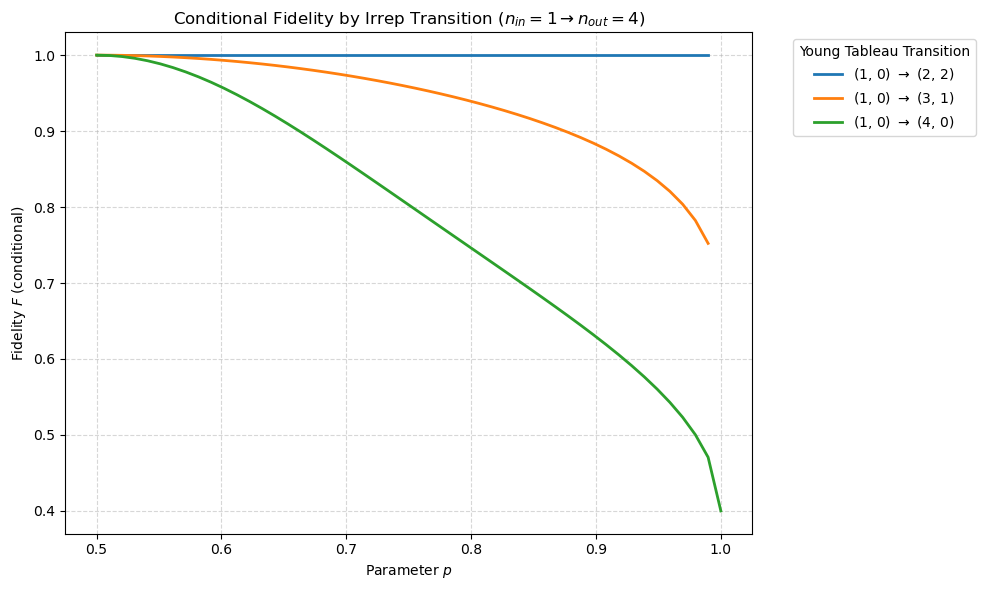

In [240]:
draw_fidelity_mine(J_blocks_local, n_in=n_in, n_out=n_out)

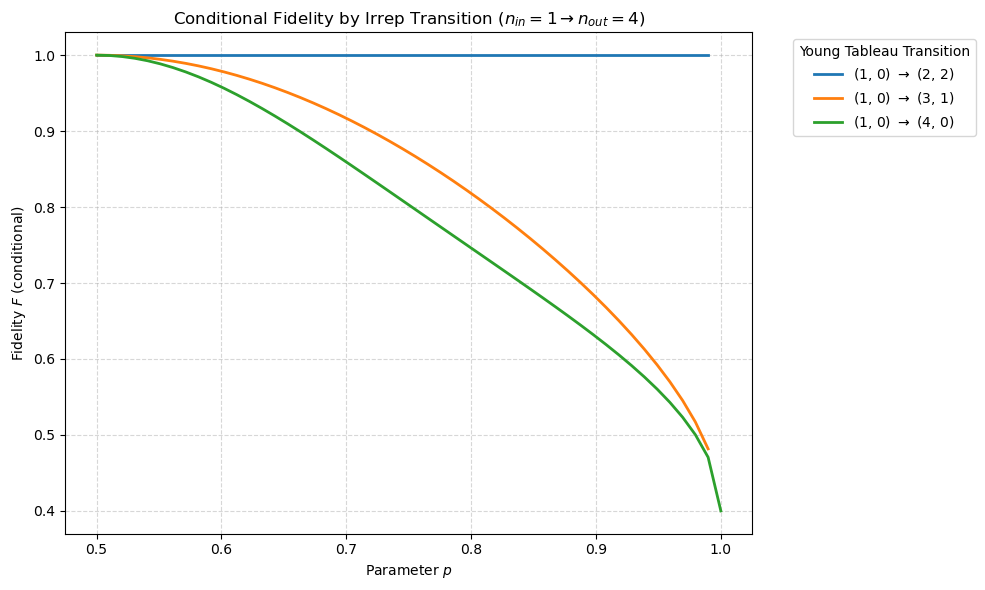

In [241]:
draw_fidelity_mine(J_blocks_global, n_in=n_in, n_out=n_out)

In [242]:
import numpy as np
import cvxpy as cp

# ------------------------------------------------------------
# Helper: hermitize & PSD project (optional but 안정성에 도움)
# ------------------------------------------------------------
def _herm(A):
    return (A + A.conj().T) / 2.0

def _psd_project(A, eps=0.0):
    A = _herm(A)
    w, v = np.linalg.eigh(A)
    w = np.clip(w, eps, None)
    return v @ np.diag(w) @ v.conj().T

# ------------------------------------------------------------
#  Alpha-optimizer with fixed local CPTP maps J_phi[(j2o,j2i)]
# ------------------------------------------------------------
class SolverAlphaMix:
    """
    Fix local CPTP Choi blocks J_phi[(j2o,j2i)] = J^{Phi}_{mu,lambda},
    optimize alpha_{lambda->mu} to maximize worst-case global root fidelity.

    Convention matches your global solver:
      sigma = Tr_in[ (I ⊗ rho^T) J ]  with left-multiply K@J in apply_choi_block_numpy.
    """
    def __init__(self,
                 n_in: int,
                 n_out: int,
                 J_phi: dict,               # (j2o,j2i) -> CPTP Choi on U_out ⊗ U_in
                 *,
                 verbose: bool = False,
                 p_init_grid: int = 5,
                 p_fine_grid: int = 81,
                 n_rounds: int = 3,
                 solver_preference=("MOSEK", "SCS"),
                 psd_project_consts: bool = True,
                 eps: float = 1e-12):
        self.n_in = n_in
        self.n_out = n_out
        self.J_phi = J_phi
        self.verbose = verbose
        self.p_init_grid = p_init_grid
        self.p_fine_grid = p_fine_grid
        self.n_rounds = n_rounds
        self.solver_preference = solver_preference
        self.psd_project_consts = psd_project_consts
        self.eps = eps

        self.j2i_list = j2_list_for_n_qubits(n_in)
        self.j2o_list = j2_list_for_n_qubits(n_out)
        self.mult_in  = {j2: mult_qubits_exact(n_in,  j2) for j2 in self.j2i_list}
        self.mult_out = {j2: mult_qubits_exact(n_out, j2) for j2 in self.j2o_list}

        # index maps
        self.i_index = {j2:i for i,j2 in enumerate(self.j2i_list)}
        self.o_index = {j2:i for i,j2 in enumerate(self.j2o_list)}

        self.p_samples = []

    def _rho_blocks_unnormalized(self, n, p, j2_list):
        # global objective uses unnormalized blocks
        return {j2: rho_spin_block(n, j2, float(p), normalize=False) for j2 in j2_list}

    def _precompute_S(self, p: float):
        """
        Precompute S[(j2o,j2i)] = Tr_in[(I⊗rho_in^T) J_phi]  (d_out x d_out)
        for a fixed p, using *unnormalized* rho blocks.
        """
        rho_in = self._rho_blocks_unnormalized(self.n_in, p, self.j2i_list)

        S = {}
        for j2o in self.j2o_list:
            d_out = j2o + 1
            for j2i in self.j2i_list:
                if (j2o, j2i) not in self.J_phi:
                    raise KeyError(f"Missing local map J_phi for pair (j2o,j2i)={(j2o,j2i)}")
                d_in = j2i + 1
                J = np.asarray(self.J_phi[(j2o, j2i)], dtype=complex)

                # channel action on U-spaces
                sig = apply_choi_block_numpy(J, rho_in[j2i], d_out, d_in)  # (d_out,d_out)
                sig = _herm(sig)
                if self.psd_project_consts:
                    sig = _psd_project(sig, eps=0.0)

                S[(j2o, j2i)] = sig
        return S

    def make_problem(self):
        # alpha matrix: rows=input j2i, cols=output j2o
        A = cp.Variable((len(self.j2i_list), len(self.j2o_list)), nonneg=True)
        t = cp.Variable()
        constraints = [t >= 0, t <= 1]

        # row-stochastic: for each lambda (input sector), sum_mu alpha_{lambda->mu} = 1
        constraints += [A @ np.ones((len(self.j2o_list), 1)) == np.ones((len(self.j2i_list), 1))]

        # constraints for each sampled p
        for p in self.p_samples:
            # target output blocks (unnormalized)
            alpha_out = self._rho_blocks_unnormalized(self.n_out, float(p), self.j2o_list)

            # precompute constant channel pieces for this p
            S = self._precompute_S(float(p))

            fid_sum = 0
            for j2o in self.j2o_list:
                d_out = j2o + 1
                m_out = self.mult_out[j2o]

                # sigma_mu(p) = sum_lambda m_in(lambda) * (alpha_{lambda->mu}/m_out(mu)) * S_{mu,lambda}(p)
                sig_expr = 0
                c = self.o_index[j2o]
                for j2i in self.j2i_list:
                    r = self.i_index[j2i]
                    m_in = self.mult_in[j2i]
                    const = (m_in / m_out) * S[(j2o, j2i)]   # (d_out,d_out) constant matrix
                    sig_expr += A[r, c] * cp.Constant(const)

                sig_expr = (sig_expr + sig_expr.H) / 2

                # Uhlmann LMI for root fidelity between unnormalized blocks alpha_out[j2o] and sig_expr
                X = cp.Variable((d_out, d_out), complex=True)
                Ablk = cp.Constant(_herm(alpha_out[j2o]))
                block = cp.bmat([[Ablk, X],
                                 [X.H, sig_expr]])
                constraints += [block >> 0]

                fid_sum += m_out * cp.real(cp.trace(X))

            constraints += [fid_sum >= t]

        prob = cp.Problem(cp.Maximize(t), constraints)
        return prob, A, t

    def solve_one_round(self):
        prob, Avar, t = self.make_problem()
        solver = choose_cvxpy_solver(self.solver_preference)
        prob.solve(solver=solver, verbose=self.verbose)

        if t.value is None or Avar.value is None:
            raise RuntimeError("Alpha-mix SDP failed (t or A is None).")

        Aopt = np.array(Avar.value, dtype=float)
        Aopt = np.clip(Aopt, 0.0, None)

        # renormalize rows (solver tiny drift)
        row_sums = Aopt.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1.0
        Aopt = Aopt / row_sums

        return float(t.value), Aopt

    def _build_global_blocks_from_alpha(self, Aopt: np.ndarray):
        """
        Build reduced global blocks:
          J_global[(j2o,j2i)] = (alpha_{lambda->mu} / m_out(mu)) * J_phi[(j2o,j2i)].
        """
        Jg = {}
        for j2i in self.j2i_list:
            r = self.i_index[j2i]
            for j2o in self.j2o_list:
                c = self.o_index[j2o]
                alpha = float(Aopt[r, c])
                m_out = self.mult_out[j2o]
                J = (alpha / m_out) * np.asarray(self.J_phi[(j2o, j2i)], dtype=complex)
                Jg[(j2o, j2i)] = _herm(J)
        return Jg

    def _eval_rootF_on_grid(self, Aopt: np.ndarray, p_grid):
        """
        Evaluate global root fidelity on p_grid.
        """
        Jg = self._build_global_blocks_from_alpha(Aopt)

        vals = []
        for p in p_grid:
            # unnormalized blocks
            rho_in  = {j2i: rho_spin_block(self.n_in,  j2i, float(p), normalize=False) for j2i in self.j2i_list}
            alpha_o = {j2o: rho_spin_block(self.n_out, j2o, float(p), normalize=False) for j2o in self.j2o_list}

            # sigma blocks
            sigma = {}
            for j2o in self.j2o_list:
                d_out = j2o + 1
                sig = np.zeros((d_out, d_out), dtype=complex)
                for j2i in self.j2i_list:
                    d_in = j2i + 1
                    sig += self.mult_in[j2i] * apply_choi_block_numpy(Jg[(j2o, j2i)], rho_in[j2i], d_out, d_in)
                sigma[j2o] = _herm(sig)

            # global root fidelity (direct-sum with multiplicities)
            rf = 0.0
            for j2o in self.j2o_list:
                rf += self.mult_out[j2o] * root_fidelity_numpy(alpha_o[j2o], sigma[j2o])
            vals.append(float(rf))

        return np.array(vals, dtype=float)

    def solve(self):
        # initial samples include p=1.0
        self.p_samples = sorted(set(np.linspace(0.5, 1.0, self.p_init_grid).tolist()))
        best = None

        for it in range(self.n_rounds):
            t_opt, Aopt = self.solve_one_round()

            # find worst p on fine grid
            p_fine = np.linspace(0.5, 1.0, self.p_fine_grid)
            fvals = self._eval_rootF_on_grid(Aopt, p_fine)
            idx = int(np.argmin(fvals))
            p_worst = float(p_fine[idx])
            f_worst = float(fvals[idx])

            if self.verbose:
                print(f"[Alpha round {it}] t_opt={t_opt:.8f} (F≈{t_opt**2:.8f})")
                print(f"              worst p={p_worst:.6f}, worst sqrtF≈{f_worst:.8f} (F≈{f_worst**2:.8f})")

            best = (t_opt, Aopt, list(self.p_samples), p_worst, f_worst)

            # constraint generation
            if min(abs(p_worst - np.array(self.p_samples))) < 1e-10:
                break
            self.p_samples.append(p_worst)
            self.p_samples = sorted(set(self.p_samples))

        # return alpha and constructed global blocks
        Aopt = best[1]
        J_global_blocks = self._build_global_blocks_from_alpha(Aopt)
        return Aopt, J_global_blocks, best



solver = SolverAlphaMix(
    n_in=n_in,
    n_out=n_out,
    J_phi=J_blocks_local,
    verbose=False,
    p_init_grid=5,
    p_fine_grid=81,
    n_rounds=3,
    solver_preference=("MOSEK","SCS"),
)

Aopt, J_blocks_local_opt, best_info = solver.solve()

In [243]:
t_opt, _, p_samples, p_worst, f_worst = best_info
print("optimized worst-case fidelity ~", f_worst**2)

print("max row-sum error:", np.max(np.abs(Aopt.sum(axis=1)-1.0)))
print("min alpha:", Aopt.min())

def check_reduced_tp(J_blocks, n_in, n_out):
    j2i_list = j2_list_for_n_qubits(n_in)
    j2o_list = j2_list_for_n_qubits(n_out)
    mult_out = {j2: mult_qubits_exact(n_out, j2) for j2 in j2o_list}

    errs = []
    for j2i in j2i_list:
        d_in = j2i + 1
        lhs = np.zeros((d_in,d_in), dtype=complex)
        for j2o in j2o_list:
            d_out = j2o + 1
            J = J_blocks[(j2o,j2i)]
            ptr = partial_trace_numpy(J, d_out, d_in, axis=0)  # trace out output
            lhs += mult_out[j2o] * ptr
        errs.append(np.linalg.norm(lhs - np.eye(d_in), ord="fro"))
    return max(errs)

print("reduced TP max Fro err:", check_reduced_tp(J_blocks_local_opt, n_in, n_out))

print("coefficients alpha_{lambda->mu}:")
print(Aopt)

optimized worst-case fidelity ~ 0.39688498158997937
max row-sum error: 0.0
min alpha: 0.0014163039856620208
reduced TP max Fro err: 2.4567315205773407e-11
coefficients alpha_{lambda->mu}:
[[0.99221267 0.00637103 0.0014163 ]]


In [244]:
J_blocks_global_saved = load_choi_blocks(f"data/sdp_perm/{n_in}_to_{n_out}.npz")

In [245]:
import numpy as np
import matplotlib.pyplot as plt


def generate_diagonal_rho(p, d):
    """
    p: 첫 번째 대각 성분의 확률 값 (0.5 <= p <= 1.0)
    d: Hilbert 공간의 차원
    """
    rho = np.zeros((d, d), dtype=complex)
    rho[0, 0] = p
    if d > 1:
        # 나머지 성분들에 대해 (1-p)를 균등 배분 (Tr(rho) = 1 유지)
        remaining_val = (1 - p) / (d - 1)
        for i in range(1, d):
            rho[i, i] = remaining_val
    return rho

def rho_blocks(n: int, p: float, j2_list):
        return {j2: rho_block_diag_in_spin_irrep(n, j2, p) for j2 in j2_list}
    
def apply_channel_blocks_numpy(J_blocks, p: float, n_in: int, n_out: int):
    j2_in_list = j2_list_for_n_qubits(n_in)
    j2_out_list = j2_list_for_n_qubits(n_out)
    rho_in = rho_blocks(n_in, float(p), j2_in_list)
    mult_in = {j2: mult_qubits(n_in, j2) for j2 in j2_in_list}
    sigma = {}
    for j2o in j2_out_list:
        d_out = j2o + 1
        sig = np.zeros((d_out, d_out), dtype=complex)
        for j2i in j2_in_list:
            d_in = j2i + 1
            J = J_blocks[(j2o, j2i)]
            K = np.kron(np.eye(d_out, dtype=complex), rho_in[j2i].T)
            M = K @ J
            sig_part = partial_trace_numpy(M, d_out, d_in, axis=1)
            sig += mult_in[j2i] * sig_part
        sigma[j2o] = (sig + sig.conj().T) / 2
    return sigma

def fidelity_block(p: float, sigma_blocks, n_out):
    j2_out_list = j2_list_for_n_qubits(n_out)
    alpha = rho_blocks(n_out, float(p), j2_out_list)
    f = 0.0
    for j2o in j2_out_list:
        f_j = fidelity_root_numpy(alpha[j2o], sigma_blocks[j2o])
        f += mult_qubits(n_out, j2o) * f_j
    return float(f) ** 2

def get_plot(A, n_in, n_out):
    n_grid = 50
    p_values = np.linspace(0.5, 1.0, n_grid)
    fidelities = []

    # 기존에 정의된 d, A, n_in, n_out 변수가 존재한다고 가정함
    for i, p in enumerate(p_values):
        sigma_blocks = apply_channel_blocks_numpy(A, float(p), n_in=n_in, n_out=n_out)
        f = fidelity_block(float(p), sigma_blocks, n_out=n_out)
        
        fidelities.append(f)
        
        # print(f"[{i+1}/{n_grid}] p = {p:.3f}, Fidelity = {f:.6f}")

    # 그래프 출력
    plt.figure(figsize=(8, 5))
    plt.plot(p_values, fidelities, label='Fidelity', color='blue', linewidth=2)
    plt.xlabel(r'parameter $p$ ($\rho(p) = \mathrm{diag}(p, 1-p)$)')
    plt.ylabel(r'Fidelity $F(\rho_{target}, \rho_{out})$')
    plt.title(f'Fidelity ({n_in} to {n_out})')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    # plt.savefig(f"figure/fidelity_{method}_{n_in}_to_{n_out}.png")
    plt.show()

    return min(fidelities)

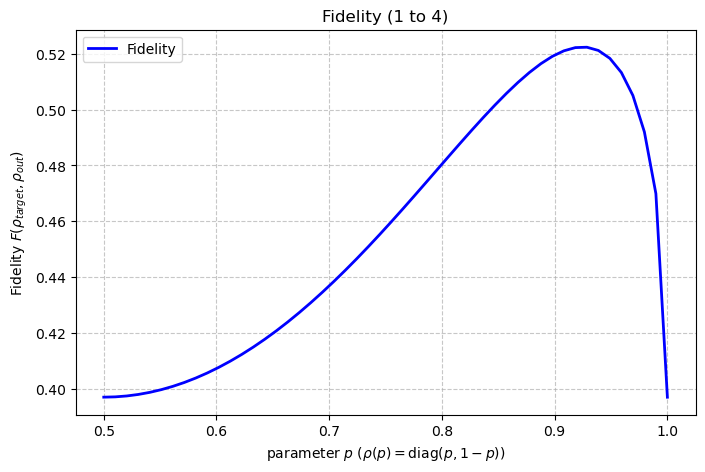

0.39688498158997937


In [246]:
min_f = get_plot(J_blocks_local_opt, n_in=n_in, n_out=n_out)
print(min_f)

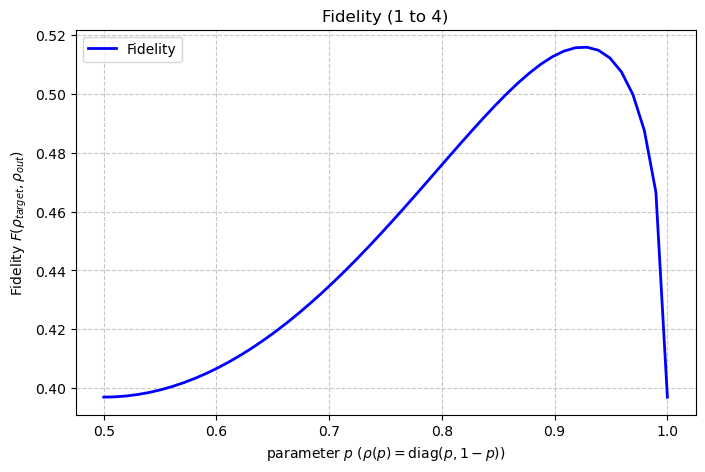

0.396884257473377


In [247]:
min_f = get_plot(J_blocks_global, n_in=n_in, n_out=n_out)
print(min_f)

In [248]:
# ============================================================
# Validation utilities for reduced Schur-spin Choi blocks
# (global / pairwise / alpha-mix)
# ============================================================

import os, sys
import numpy as np
import pandas as pd

# ---- robust import of utils.py (same dir as notebook OR fallback path)
if "utils" not in sys.modules:
    if os.path.exists("utils.py"):
        sys.path.insert(0, os.getcwd())
    elif os.path.exists("/mnt/data/utils.py"):
        sys.path.insert(0, "/mnt/data")

import utils as u


# ---------------------------
# Basic linear-algebra helpers
# ---------------------------
def vcheck_herm(A: np.ndarray) -> np.ndarray:
    return (A + A.conj().T) / 2.0

def vcheck_fro(A: np.ndarray) -> float:
    return float(np.linalg.norm(A, ord="fro"))

def vcheck_rel_fro(A: np.ndarray, B: np.ndarray, eps: float = 1e-15) -> float:
    return vcheck_fro(A - B) / max(eps, vcheck_fro(B))

def vcheck_min_eig_herm(A: np.ndarray) -> float:
    w = np.linalg.eigvalsh(vcheck_herm(A))
    return float(np.min(np.real(w)))

def vcheck_max_abs_imag(A: np.ndarray) -> float:
    return float(np.max(np.abs(np.imag(A))))


# ------------------------------------------------------------
# Choi application checks (indexing consistency)
# Convention your notebook uses at reduced-block level:
#   sigma = Tr_in[ (I_out ⊗ rho^T) J ]  (but order doesn't matter after Tr_in)
# Key check = reshape order + partial trace axis correctness.
# ------------------------------------------------------------
def vcheck_apply_choi_via_kron(J: np.ndarray, rho: np.ndarray, d_out: int, d_in: int) -> np.ndarray:
    K = np.kron(np.eye(d_out, dtype=complex), rho.T)
    M = K @ J
    sig = u.partial_trace_numpy(M, d_out, d_in, axis=1)  # trace out input
    return vcheck_herm(sig)

def vcheck_apply_choi_via_einsum(J: np.ndarray, rho: np.ndarray, d_out: int, d_in: int) -> np.ndarray:
    # This matches the kron+partial_trace route if reshape/order is consistent
    J4 = J.reshape(d_out, d_in, d_out, d_in)  # IMPORTANT: (out,in,out,in) in row-major
    sig = np.einsum("aibj,ij->ab", J4, rho)
    return vcheck_herm(sig)

def vcheck_sanity_tensor_indexing(d: int = 5, seed: int = 0):
    """
    Random J and random rho:
      kron+partial_trace result must match einsum contraction.
    If this fails, your partial_trace axis or reshape ordering is inconsistent.
    """
    rng = np.random.default_rng(seed)
    J = rng.normal(size=(d*d, d*d)) + 1j * rng.normal(size=(d*d, d*d))
    X = rng.normal(size=(d, d)) + 1j * rng.normal(size=(d, d))
    rho = X @ X.conj().T
    rho = rho / np.trace(rho)

    s1 = vcheck_apply_choi_via_kron(J, rho, d_out=d, d_in=d)
    s2 = vcheck_apply_choi_via_einsum(J, rho, d_out=d, d_in=d)
    err = vcheck_fro(s1 - s2)

    print("== sanity: kron+partial_trace vs einsum ==")
    print("d =", d, "  Fro error =", err)
    return err


# ------------------------------------------------------------
# SU(2) commutant/covariance check:
#   J must commute with Gx,Gy,Gz where
#     G = S_out ⊗ I - I ⊗ (S_in)^T
# ------------------------------------------------------------
def vcheck_su2_generators(j2_out: int, j2_in: int):
    d_out = j2_out + 1
    d_in  = j2_in + 1
    Iout = np.eye(d_out, dtype=complex)
    Iin  = np.eye(d_in, dtype=complex)
    Sx_o, Sy_o, Sz_o = u.spin_matrices_from_j2(j2_out)
    Sx_i, Sy_i, Sz_i = u.spin_matrices_from_j2(j2_in)
    Gx = np.kron(Sx_o, Iin) - np.kron(Iout, Sx_i.T)
    Gy = np.kron(Sy_o, Iin) - np.kron(Iout, Sy_i.T)
    Gz = np.kron(Sz_o, Iin) - np.kron(Iout, Sz_i.T)
    return Gx, Gy, Gz

def vcheck_comm_rel_norm(J: np.ndarray, G: np.ndarray, eps: float = 1e-15) -> float:
    return vcheck_fro(G @ J - J @ G) / max(eps, vcheck_fro(J))


# ------------------------------------------------------------
# Main per-block report
# kind:
#   "global"  : SDPPerm result blocks (subnormalized)
#   "pairwise": SDPIrrepPair result blocks (CPTP per block)
#   "mixed"   : alpha-mix result blocks (subnormalized)
# ------------------------------------------------------------
def vcheck_block_report(
    J_blocks: dict,
    n_in: int,
    n_out: int,
    *,
    kind: str,                 # "global" | "pairwise" | "mixed"
    tol_herm: float = 1e-7,
    tol_psd: float  = 1e-8,
    tol_tp: float   = 1e-7,
    tol_comm: float = 1e-7,
):
    j2i_list = u.j2_list_for_n_qubits(n_in)
    j2o_list = u.j2_list_for_n_qubits(n_out)
    mult_out = {j2: u.mult_qubits(n_out, j2) for j2 in j2o_list}

    rows = []
    for j2o in j2o_list:
        d_out = j2o + 1
        for j2i in j2i_list:
            d_in = j2i + 1
            key = (j2o, j2i)

            if key not in J_blocks:
                rows.append(dict(
                    j2_out=j2o, j2_in=j2i,
                    present=False,
                    d_out=d_out, d_in=d_in,
                    shape_ok=False,
                    herm_err=np.nan, min_eig=np.nan,
                    trace=np.nan, ptr_out_scalar=np.nan,
                    ptr_out_dev=np.nan, tp_err=np.nan,
                    comm_err=np.nan,
                    imag_max=np.nan,
                    m_out=mult_out[j2o]
                ))
                continue

            J = np.asarray(J_blocks[key], dtype=complex)
            shape_ok = (J.shape == (d_out * d_in, d_out * d_in))
            if not shape_ok:
                rows.append(dict(
                    j2_out=j2o, j2_in=j2i,
                    present=True,
                    d_out=d_out, d_in=d_in,
                    shape_ok=False,
                    herm_err=np.nan, min_eig=np.nan,
                    trace=np.nan, ptr_out_scalar=np.nan,
                    ptr_out_dev=np.nan, tp_err=np.nan,
                    comm_err=np.nan,
                    imag_max=vcheck_max_abs_imag(J),
                    m_out=mult_out[j2o]
                ))
                continue

            herm_err = vcheck_fro(J - J.conj().T) / max(1e-15, vcheck_fro(J))
            min_eig  = vcheck_min_eig_herm(J)
            trJ      = np.trace(J)

            # partial trace over output
            ptr_out = u.partial_trace_numpy(J, d_out, d_in, axis=0)
            ptr_out = vcheck_herm(ptr_out)
            scalar  = np.trace(ptr_out) / d_in  # should be real (numerically)
            ptr_dev = vcheck_fro(ptr_out - scalar * np.eye(d_in)) / max(1e-15, vcheck_fro(ptr_out))

            # TP expectation differs by kind:
            # - pairwise: Tr_out(J)=I
            # - global/mixed: each block is subnormalized, but should still satisfy Tr_out(J)=scalar*I
            if kind.lower() == "pairwise":
                tp_err = vcheck_fro(ptr_out - np.eye(d_in))
            else:
                tp_err = ptr_dev  # per-block "scalar*I" deviation

            # SU(2) commutant check
            Gx, Gy, Gz = vcheck_su2_generators(j2o, j2i)
            comm_err = max(
                vcheck_comm_rel_norm(J, Gx),
                vcheck_comm_rel_norm(J, Gy),
                vcheck_comm_rel_norm(J, Gz),
            )

            rows.append(dict(
                j2_out=j2o, j2_in=j2i,
                present=True,
                d_out=d_out, d_in=d_in,
                shape_ok=True,
                herm_err=herm_err,
                min_eig=min_eig,
                trace=float(np.real_if_close(trJ)),
                imag_max=vcheck_max_abs_imag(trJ),
                ptr_out_scalar=float(np.real_if_close(scalar)),
                ptr_out_dev=ptr_dev,
                tp_err=tp_err,
                comm_err=comm_err,
                m_out=mult_out[j2o]
            ))

    df_blocks = pd.DataFrame(rows)

    # reduced TP check (global/mixed only)
    df_tp = pd.DataFrame()
    if kind.lower() in ("global", "mixed"):
        tp_rows = []
        for j2i in j2i_list:
            d_in = j2i + 1
            lhs = np.zeros((d_in, d_in), dtype=complex)
            present_any = False
            for j2o in j2o_list:
                key = (j2o, j2i)
                if key not in J_blocks:
                    continue
                present_any = True
                d_out = j2o + 1
                ptr = u.partial_trace_numpy(np.asarray(J_blocks[key], dtype=complex), d_out, d_in, axis=0)
                lhs += mult_out[j2o] * vcheck_herm(ptr)
            err = vcheck_fro(lhs - np.eye(d_in)) if present_any else np.nan
            tp_rows.append(dict(j2_in=j2i, d_in=d_in, reduced_tp_fro_err=err))
        df_tp = pd.DataFrame(tp_rows)

    # inferred alpha (global/mixed only):
    # w = Tr(J)/d_in  (since Tr_out(J)=w I), alpha = m_out * w
    df_alpha = pd.DataFrame()
    if kind.lower() in ("global", "mixed"):
        alpha_rows = []
        for j2i in j2i_list:
            d_in = j2i + 1
            for j2o in j2o_list:
                key = (j2o, j2i)
                if key not in J_blocks:
                    continue
                J = np.asarray(J_blocks[key], dtype=complex)
                w = np.trace(J) / d_in
                alpha = mult_out[j2o] * w
                alpha_rows.append(dict(
                    j2_in=j2i, j2_out=j2o,
                    w=float(np.real_if_close(w)),
                    alpha=float(np.real_if_close(alpha)),
                ))
        df_alpha = pd.DataFrame(alpha_rows)
        if len(df_alpha) > 0:
            rs = (df_alpha.groupby("j2_in")["alpha"].sum()
                  .reset_index()
                  .rename(columns={"alpha":"alpha_row_sum"}))
            df_alpha = df_alpha.merge(rs, on="j2_in", how="left")

    # pass flags
    if len(df_blocks) > 0:
        df_blocks["pass_herm"] = df_blocks["herm_err"] <= tol_herm
        df_blocks["pass_psd"]  = df_blocks["min_eig"] >= -tol_psd
        df_blocks["pass_comm"] = df_blocks["comm_err"] <= tol_comm
        if kind.lower() == "pairwise":
            df_blocks["pass_tp"] = df_blocks["tp_err"] <= tol_tp
        else:
            df_blocks["pass_tp"] = df_blocks["ptr_out_dev"] <= tol_tp

    return df_blocks, df_tp, df_alpha


def vcheck_summarize(name: str, df_blocks: pd.DataFrame, df_tp: pd.DataFrame, df_alpha: pd.DataFrame):
    print("\n" + "="*72)
    print(f"[{name}] SUMMARY")
    print("="*72)

    if len(df_blocks) == 0:
        print("No blocks found.")
        return

    present = df_blocks[df_blocks["present"] == True]
    print(f"blocks present: {len(present)} / total entries: {len(df_blocks)}")

    def worst(col):
        if len(present) == 0:
            return np.nan
        return float(np.nanmax(present[col].values))

    def best(col):
        if len(present) == 0:
            return np.nan
        return float(np.nanmin(present[col].values))

    print("worst herm_err :", worst("herm_err"))
    print("min min_eig   :", best("min_eig"))
    print("worst comm_err:", worst("comm_err"))
    if "tp_err" in present.columns:
        print("worst tp_err  :", worst("tp_err"))

    # flag counts
    for flag in ["pass_herm","pass_psd","pass_comm","pass_tp"]:
        if flag in df_blocks.columns:
            fail = int(np.sum((present[flag] == False).values))
            print(f"failed {flag}: {fail}")

    # reduced TP for global/mixed
    if len(df_tp) > 0:
        print("\nReduced TP errors (per input irrep):")
        print(df_tp.to_string(index=False, float_format="{:.3e}".format))

    # alpha row-sum for global/mixed
    if len(df_alpha) > 0:
        rs = df_alpha[["j2_in","alpha_row_sum"]].drop_duplicates().sort_values("j2_in", ascending=False)
        print("\nInferred alpha row-sums (should be ~1):")
        print(rs.to_string(index=False, float_format="{:.12f}".format))
        print("min alpha inferred:", float(np.min(df_alpha["alpha"].values)))
        print("min w inferred    :", float(np.min(df_alpha["w"].values)))


# ------------------------------------------------------------
# AlphaMix reconstruction check:
# if you have Aopt and J_phi (pairwise CPTP blocks), then
# reconstructed blocks must match J_blocks_local_opt
# ------------------------------------------------------------
def vcheck_reconstruct_from_alpha(A: np.ndarray, J_phi: dict, n_in: int, n_out: int):
    j2i_list = u.j2_list_for_n_qubits(n_in)
    j2o_list = u.j2_list_for_n_qubits(n_out)
    mult_out = {j2: u.mult_qubits(n_out, j2) for j2 in j2o_list}

    if A.shape != (len(j2i_list), len(j2o_list)):
        raise ValueError(f"A shape {A.shape} != {(len(j2i_list), len(j2o_list))} implied by j2 lists")

    J_rec = {}
    for r, j2i in enumerate(j2i_list):
        for c, j2o in enumerate(j2o_list):
            key = (j2o, j2i)
            if key not in J_phi:
                continue
            if mult_out[j2o] == 0:
                continue
            alpha = float(A[r, c])
            J_rec[key] = (alpha / mult_out[j2o]) * np.asarray(J_phi[key], dtype=complex)
    return J_rec

def vcheck_compare_blocks(J_a: dict, J_b: dict, n_in: int, n_out: int):
    j2i_list = u.j2_list_for_n_qubits(n_in)
    j2o_list = u.j2_list_for_n_qubits(n_out)
    rows = []
    for j2o in j2o_list:
        for j2i in j2i_list:
            key = (j2o, j2i)
            if key not in J_a or key not in J_b:
                continue
            A = np.asarray(J_a[key], dtype=complex)
            B = np.asarray(J_b[key], dtype=complex)
            rows.append(dict(j2_out=j2o, j2_in=j2i, rel_fro_err=vcheck_rel_fro(A, B)))
    df = pd.DataFrame(rows)
    if len(df) == 0:
        return df
    return df.sort_values(["j2_in","j2_out"], ascending=[False, False]).reset_index(drop=True)


# ============================================================
# QUICK RUN TEMPLATE
# ============================================================

print(">>> (0) indexing sanity check (THIS SHOULD BE ~ 1e-12 or smaller)")
_ = vcheck_sanity_tensor_indexing(d=6, seed=0)

# Example usage (uncomment what you have in your workspace):
# dfG, dfG_tp, dfG_alpha = vcheck_block_report(J_blocks_global, n_in, n_out, kind="global")
# vcheck_summarize("GLOBAL (SDPPerm)", dfG, dfG_tp, dfG_alpha)

# dfL, dfL_tp, dfL_alpha = vcheck_block_report(J_blocks_local, n_in, n_out, kind="pairwise")
# vcheck_summarize("PAIRWISE (SDPIrrepPair)", dfL, dfL_tp, dfL_alpha)

# dfM, dfM_tp, dfM_alpha = vcheck_block_report(J_blocks_local_opt, n_in, n_out, kind="mixed")
# vcheck_summarize("MIXED (AlphaMix)", dfM, dfM_tp, dfM_alpha)

# If you have Aopt and J_blocks_local (as J_phi):
# J_rec = vcheck_reconstruct_from_alpha(Aopt, J_blocks_local, n_in, n_out)
# df_cmp = vcheck_compare_blocks(J_rec, J_blocks_local_opt, n_in, n_out)
# print("\n[AlphaMix reconstruction] per-block relative Fro errors:")
# print(df_cmp.to_string(index=False, float_format="{:.3e}".format))
# print("worst rel error:", df_cmp["rel_fro_err"].max())

dfG, dfG_tp, dfG_alpha = vcheck_block_report(J_blocks_global, n_in, n_out, kind="global")
vcheck_summarize("GLOBAL (SDPPerm)", dfG, dfG_tp, dfG_alpha)

dfL, _, _ = vcheck_block_report(J_blocks_local, n_in, n_out, kind="pairwise")
vcheck_summarize("PAIRWISE (SDPIrrepPair)", dfL, pd.DataFrame(), pd.DataFrame())

dfM, dfM_tp, dfM_alpha = vcheck_block_report(J_blocks_local_opt, n_in, n_out, kind="mixed")
vcheck_summarize("MIXED (AlphaMix)", dfM, dfM_tp, dfM_alpha)

J_rec = vcheck_reconstruct_from_alpha(Aopt, J_blocks_local, n_in, n_out)
df_cmp = vcheck_compare_blocks(J_rec, J_blocks_local_opt, n_in, n_out)
print(df_cmp.to_string(index=False, float_format="{:.3e}".format))
print("worst rel error:", df_cmp["rel_fro_err"].max())



>>> (0) indexing sanity check (THIS SHOULD BE ~ 1e-12 or smaller)
== sanity: kron+partial_trace vs einsum ==
d = 6   Fro error = 6.050779143449325e-16

[GLOBAL (SDPPerm)] SUMMARY
blocks present: 3 / total entries: 3
worst herm_err : 0.0
min min_eig   : 1.453824009449162e-07
worst comm_err: 6.480929963716387e-16
worst tp_err  : 7.91208950206251e-17
failed pass_herm: 0
failed pass_psd: 0
failed pass_comm: 0
failed pass_tp: 0

Reduced TP errors (per input irrep):
 j2_in  d_in  reduced_tp_fro_err
     1     2           1.424e-10

Inferred alpha row-sums (should be ~1):
 j2_in  alpha_row_sum
     1 0.999999999899
min alpha inferred: 0.0014165463808704275
min w inferred    : 0.0007082731904352138

[PAIRWISE (SDPIrrepPair)] SUMMARY
blocks present: 3 / total entries: 3
worst herm_err : 0.0
min min_eig   : 6.138053065321773e-10
worst comm_err: 6.304409752125806e-16
worst tp_err  : 2.640459814849253e-10
failed pass_herm: 0
failed pass_psd: 0
failed pass_comm: 0
failed pass_tp: 0

[MIXED (AlphaMi